# HLDA-style summary at fixed thresholds

Build a tidy table for all mutants using the HLDA eigenvalue (λ) at fixed RMSD thresholds and derived statistics for variance shifts and RMSD. Thresholds: MFPT thr=0.46, folded rmsd<=0.25, unfolded rmsd>=0.68.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from common.colvar_utils import read_colvar_header_names, load_colvar
from common.hlda_utils import (
    hlda_from_moments,
    prune,
    moments_from_mask,
    state_mean,
)

# --- fixed analysis settings ---
tF = 0.25
tU = 0.68
mfpt_threshold = 0.46
sample_n = 1_000_000
corr_prune_thresh = 0.93

base_dir = Path("../data/traj")
f_filename = "COLVAR_CV_F"
uf_filename = "COLVAR_CV_UF"
rmsd_col = "rmsd_ca"
wildtype_alias = {"Wildtype": "WT"}
skip_dirs = {"T7Q", "P3R"}

# skip_dirs = {}

In [ ]:
def mfpt_table_to_L_MFPT(df_raw: pd.DataFrame) -> pd.DataFrame:
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()
    df["Mutant"] = df["Mutant"].astype(str).str.strip().replace(wildtype_alias)
    df["MFPT"] = df["mfpt"] / 1e6  # fs -> us
    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["L_MFPT"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "L_MFPT"]]


def correlation_heatmap(corr: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="YlOrRd")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    for (i, j), val in np.ndenumerate(corr.to_numpy()):
        if np.isfinite(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="Spearman rho")
    fig.tight_layout()
    return fig, ax


In [ ]:
# --- Wildtype reference stats ---
wt_dir = base_dir / "WT"
wt_f_path = wt_dir / f_filename
wt_uf_path = wt_dir / uf_filename

wt_names = read_colvar_header_names(wt_f_path)
wt_desc_cols = [c for c in wt_names if c.startswith("d")]
usecols = wt_desc_cols + [rmsd_col]

wt_F = load_colvar(wt_f_path, usecols, sample_n)
wt_U = load_colvar(wt_uf_path, usecols, sample_n)

wt_mask_F = wt_F[rmsd_col] <= tF
wt_mask_U = wt_U[rmsd_col] >= tU

wt_var_F = wt_F.loc[wt_mask_F, wt_desc_cols].var(ddof=1)
wt_var_U = wt_U.loc[wt_mask_U, wt_desc_cols].var(ddof=1)

results = []

for protein_dir in sorted(d for d in base_dir.iterdir() if d.is_dir()):
    short = protein_dir.name
    if short in skip_dirs:
        continue

    f_path = protein_dir / f_filename
    uf_path = protein_dir / uf_filename
    if not (f_path.exists() and uf_path.exists()):
        continue

    names = read_colvar_header_names(f_path)
    desc_cols = [c for c in names if c.startswith("d")]
    if rmsd_col not in names or not desc_cols:
        continue

    desc_use = [c for c in desc_cols if c in wt_desc_cols]
    if not desc_use:
        continue

    usecols = desc_use + [rmsd_col]
    df_F = load_colvar(f_path, usecols, sample_n)
    df_U = load_colvar(uf_path, usecols, sample_n)

    mask_F = df_F[rmsd_col] <= tF
    mask_U = df_U[rmsd_col] >= tU

    muF, covF, nF = moments_from_mask(df_F, desc_use, mask_F)
    muU, covU, nU = moments_from_mask(df_U, desc_use, mask_U)

    lam = np.nan
    kept_desc = np.nan
    if muF is not None and muU is not None:
        kept_cols, keep_idx = prune(covF, covU, desc_use, threshold=corr_prune_thresh)
        if keep_idx:
            muF_r = muF[keep_idx]
            covF_r = covF[np.ix_(keep_idx, keep_idx)]
            muU_r = muU[keep_idx]
            covU_r = covU[np.ix_(keep_idx, keep_idx)]
            _, lam_val = hlda_from_moments(muF_r, covF_r, muU_r, covU_r, kept_cols)
            lam = lam_val
            kept_desc = len(kept_cols)

    delta_F = np.nan
    if mask_F.sum() >= 2:
        var_F = df_F.loc[mask_F, desc_use].var(ddof=1)
        delta_F = float(np.abs(var_F - wt_var_F.loc[desc_use]).sum())

    delta_U = np.nan
    if mask_U.sum() >= 2:
        var_U = df_U.loc[mask_U, desc_use].var(ddof=1)
        delta_U = float(np.abs(var_U - wt_var_U.loc[desc_use]).sum())

    deltas = [d for d in (delta_F, delta_U) if pd.notna(d)]
    abs_var_delta_mean = float(np.mean(deltas)) if deltas else np.nan
    abs_var_delta_sum = float(np.sum(deltas)) if deltas else np.nan

    results.append({
        "Mutant": wildtype_alias.get(short, short),
        "lambda": lam,
        "n_desc_kept": kept_desc,
        "abs_var_delta_mean": abs_var_delta_mean,
        "abs_var_delta_sum": abs_var_delta_sum,
        "abs_var_delta_F": delta_F,
        "abs_var_delta_U": delta_U,
        "mean_rmsd_F": state_mean(df_F[rmsd_col], mask_F),
        "mean_rmsd_U": state_mean(df_U[rmsd_col], mask_U),
        # "frames_F": int(mask_F.sum()),
        # "frames_U": int(mask_U.sum()),
    })

result_df = pd.DataFrame(results)
display(result_df.sort_values("Mutant").reset_index(drop=True))


,lambda,abs_var_delta_mean,abs_var_delta_sum,abs_var_delta_F,abs_var_delta_U,mean_rmsd_F,mean_rmsd_U,L_MFPT
lambda,NaN,0.009781,0.009781,0.514801,0.008237,0.177864,0.061776,0.638375
abs_var_delta_mean,0.009781,NaN,1.000000,0.127156,0.997941,0.152381,0.152381,0.031653
abs_var_delta_sum,0.009781,1.000000,NaN,0.127156,0.997941,0.152381,0.152381,0.031653
abs_var_delta_F,0.514801,0.127156,0.127156,NaN,0.155985,0.007207,0.360360,0.461064
abs_var_delta_U,0.008237,0.997941,0.997941,0.155985,NaN,0.132304,0.171171,0.013165
mean_rmsd_F,0.177864,0.152381,0.152381,0.007207,0.132304,NaN,0.112227,0.024370
mean_rmsd_U,0.061776,0.152381,0.152381,0.360360,0.171171,0.112227,NaN,0.208123
L_MFPT,0.638375,0.031653,0.031653,0.461064,0.013165,0.024370,0.208123,NaN


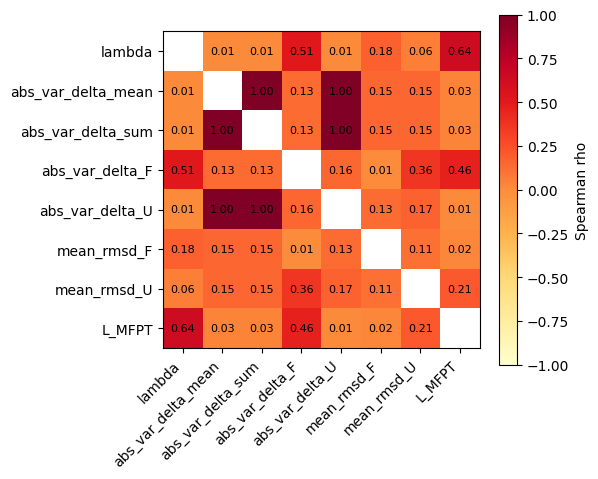

In [ ]:
# --- MFPT merge (thr=0.46) and correlations ---
mfpt_pkl = Path("../data/mfpt_all_thresholds-new-ref.pkl")
with mfpt_pkl.open("rb") as f:
    mfpt_tables = pickle.load(f)

if not mfpt_tables:
    raise ValueError("No MFPT data found in pickle")

closest_thr = min(mfpt_tables.keys(), key=lambda x: abs(float(x) - mfpt_threshold))
df_mfpt = mfpt_table_to_L_MFPT(mfpt_tables[closest_thr])

merged = result_df.merge(df_mfpt, on="Mutant", how="left")

metrics_cols = [
    "lambda",
    "abs_var_delta_mean",
    "abs_var_delta_sum",
    "abs_var_delta_F",
    "abs_var_delta_U",
    "mean_rmsd_F",
    "mean_rmsd_U",
    "L_MFPT",
]

corr = np.abs(merged[metrics_cols].corr(method="spearman"))
# corr = corr[~np.isclose(corr, 1.0)]

# Alternatively, just mask the diagonal if that's the only 1.0 source
np.fill_diagonal(corr.values, np.nan)

display(corr)
correlation_heatmap(corr)
plt.show()


/tmp/ipykernel_773417/1531531363.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_773417/1531531363.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_773417/1531531363.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

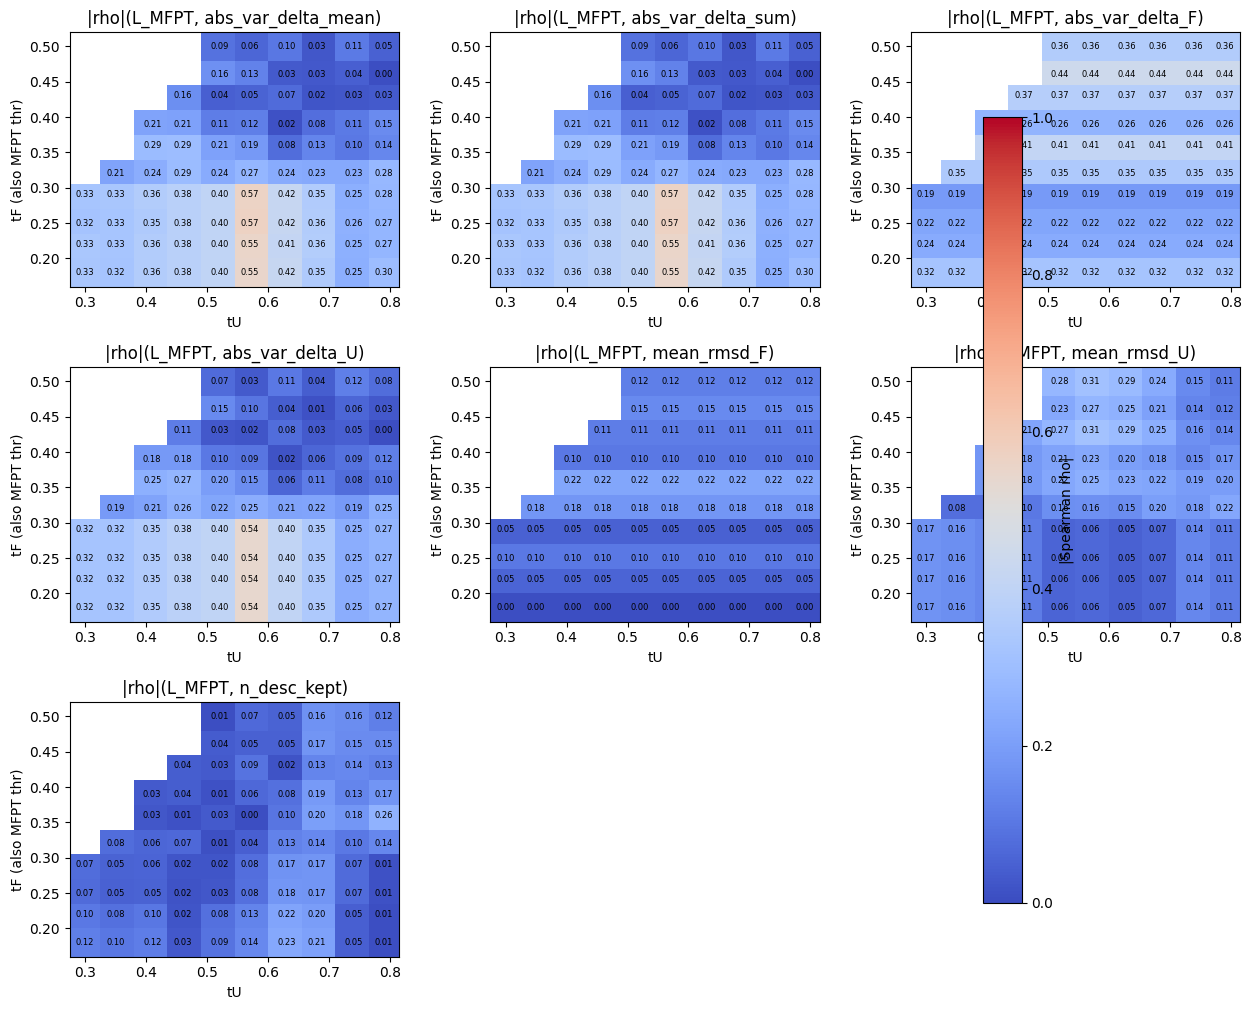

In [ ]:
# --- Threshold grid exploration: |rho| of L_MFPT (MFPT thr tied to tF) vs variance/RMSD/n_desc ---
tF_grid = np.round(np.linspace(0.18, 0.50, 10), 2)
tU_grid = np.round(np.linspace(0.30, 0.79, 10), 2)

# Load MFPT tables and map thresholds to L_MFPT series
mfpt_pkl = Path("../data/mfpt_all_thresholds-new-ref.pkl")
with mfpt_pkl.open("rb") as f:
    mfpt_tables = pickle.load(f)

mfpt_thr_to_series = {}
for thr, tbl in mfpt_tables.items():
    df_thr = mfpt_table_to_L_MFPT(tbl).set_index("Mutant")["L_MFPT"]
    mfpt_thr_to_series[float(thr)] = df_thr
mfpt_thr_values = sorted(mfpt_thr_to_series.keys())

def closest_mfpt_thr(val: float) -> float:
    return min(mfpt_thr_values, key=lambda x: abs(x - val))

# Preload WT trajectories (intersection of descriptors used above)
wt_F_full = load_colvar(wt_f_path, wt_desc_cols + [rmsd_col], sample_n)
wt_U_full = load_colvar(wt_uf_path, wt_desc_cols + [rmsd_col], sample_n)

wt_var_F_grid = {}
wt_var_U_grid = {}
for tF_val in tF_grid:
    mask = wt_F_full[rmsd_col] <= tF_val
    wt_var_F_grid[tF_val] = wt_F_full.loc[mask, wt_desc_cols].var(ddof=1) if mask.sum() >= 2 else None
for tU_val in tU_grid:
    mask = wt_U_full[rmsd_col] >= tU_val
    wt_var_U_grid[tU_val] = wt_U_full.loc[mask, wt_desc_cols].var(ddof=1) if mask.sum() >= 2 else None

grid_results = []

for protein_dir in sorted(d for d in base_dir.iterdir() if d.is_dir()):
    short = protein_dir.name
    if short in skip_dirs:
        continue

    f_path = protein_dir / f_filename
    uf_path = protein_dir / uf_filename
    if not (f_path.exists() and uf_path.exists()):
        continue

    names = read_colvar_header_names(f_path)
    desc_cols = [c for c in names if c.startswith("d")]
    if rmsd_col not in names or not desc_cols:
        continue

    desc_use = [c for c in desc_cols if c in wt_desc_cols]
    if not desc_use:
        continue

    usecols = desc_use + [rmsd_col]
    df_F = load_colvar(f_path, usecols, sample_n)
    df_U = load_colvar(uf_path, usecols, sample_n)

    for tF_val in tF_grid:
        mask_F = df_F[rmsd_col] <= tF_val
        muF, covF, nF = moments_from_mask(df_F, desc_use, mask_F)
        var_F = df_F.loc[mask_F, desc_use].var(ddof=1) if mask_F.sum() >= 2 else None

        for tU_val in tU_grid:
            if tU_val <= tF_val:
                continue
            mask_U = df_U[rmsd_col] >= tU_val
            muU, covU, nU = moments_from_mask(df_U, desc_use, mask_U)
            var_U = df_U.loc[mask_U, desc_use].var(ddof=1) if mask_U.sum() >= 2 else None

            lam = np.nan
            kept_desc = np.nan
            if muF is not None and muU is not None:
                kept_cols, keep_idx = prune(covF, covU, desc_use, threshold=corr_prune_thresh)
                if keep_idx:
                    muF_r = muF[keep_idx]
                    covF_r = covF[np.ix_(keep_idx, keep_idx)]
                    muU_r = muU[keep_idx]
                    covU_r = covU[np.ix_(keep_idx, keep_idx)]
                    _, lam_val = hlda_from_moments(muF_r, covF_r, muU_r, covU_r, kept_cols)
                    lam = lam_val
                    kept_desc = len(kept_cols)

            delta_F = np.nan
            if var_F is not None and wt_var_F_grid.get(tF_val) is not None:
                delta_F = float(np.abs(var_F - wt_var_F_grid[tF_val].loc[desc_use]).sum())

            delta_U = np.nan
            if var_U is not None and wt_var_U_grid.get(tU_val) is not None:
                delta_U = float(np.abs(var_U - wt_var_U_grid[tU_val].loc[desc_use]).sum())

            deltas = [d for d in (delta_F, delta_U) if pd.notna(d)]
            abs_var_delta_mean = float(np.mean(deltas)) if deltas else np.nan
            abs_var_delta_sum = float(np.sum(deltas)) if deltas else np.nan

            mfpt_thr = closest_mfpt_thr(float(tF_val))
            mfpt_series = mfpt_thr_to_series[mfpt_thr]
            mut_label = wildtype_alias.get(short, short)
            l_mfpt_val = mfpt_series.get(mut_label, np.nan)

            grid_results.append({
                "Mutant": mut_label,
                "tF": float(tF_val),
                "tU": float(tU_val),
                "mfpt_thr": mfpt_thr,
                "lambda": lam,
                "n_desc_kept": kept_desc,
                "abs_var_delta_mean": abs_var_delta_mean,
                "abs_var_delta_sum": abs_var_delta_sum,
                "abs_var_delta_F": delta_F,
                "abs_var_delta_U": delta_U,
                "mean_rmsd_F": state_mean(df_F[rmsd_col], mask_F),
                "mean_rmsd_U": state_mean(df_U[rmsd_col], mask_U),
                "L_MFPT": l_mfpt_val,
            })

grid_df = pd.DataFrame(grid_results)

metrics = [
    "abs_var_delta_mean",
    "abs_var_delta_sum",
    "abs_var_delta_F",
    "abs_var_delta_U",
    "mean_rmsd_F",
    "mean_rmsd_U",
    "n_desc_kept",      # descriptor retention
]

def corr_by_threshold(df, metric):
    return (
        df.dropna(subset=["L_MFPT", metric])
        .groupby(["tF", "tU"])
        .apply(lambda g: pd.Series({
            "rho_abs": abs(g["L_MFPT"].corr(g[metric], method="spearman")),
            "n": len(g)
        }))
        .reset_index()
    )

# Quick heatmaps of |Spearman rho| over (tF, tU) grid

def edges_from_centers(c):
    c = np.asarray(c, float)
    if c.size == 0:
        return c
    d = np.diff(c)
    edges = np.empty(c.size + 1, float)
    if c.size == 1:
        edges[0] = c[0] - 0.5
        edges[1] = c[0] + 0.5
        return edges
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges

corr_maps = {m: corr_by_threshold(grid_df, m) for m in metrics}

ncols = 3
nrows = int(np.ceil(len(metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False)

for ax, metric in zip(axes.ravel(), metrics):
    corr_df = corr_maps[metric]
    P = corr_df.pivot(index="tF", columns="tU", values="rho_abs").sort_index()
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)
    im = ax.pcolormesh(x_edges, y_edges, P.values, vmin=0, vmax=1, cmap="YlOrRd", shading="flat")
    for i, tF_val in enumerate(y_centers):
        for j, tU_val in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU_val, tF_val, f"{val:.2f}", ha="center", va="center", fontsize=6)
    ax.set_xlabel("tU")
    ax.set_ylabel("tF (also MFPT thr)")
    ax.set_title(f"|rho|(L_MFPT, {metric})")

for ax in axes.ravel()[len(metrics):]:
    ax.axis("off")

fig.tight_layout()
plt.show()


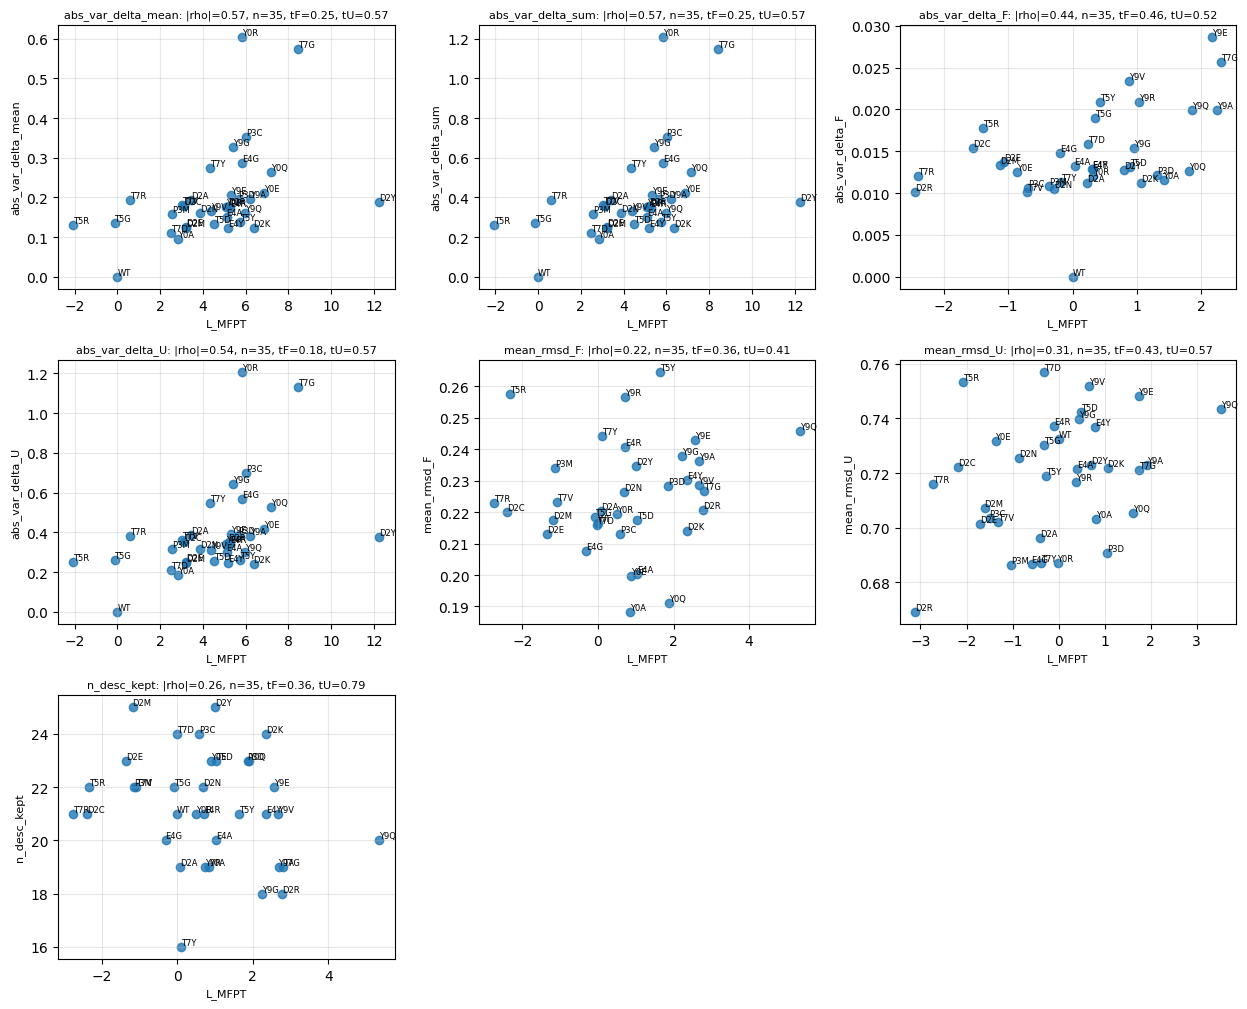

In [ ]:
# --- Scatter plots at best |rho| per metric (L_MFPT vs metric) ---
best_points = {}
for metric, corr_df in corr_maps.items():
    df = corr_df.dropna(subset=["rho_abs"])
    if df.empty:
        continue
    idx = df["rho_abs"].idxmax()
    row = corr_df.loc[idx]
    best_points[metric] = {
        "tF": float(row["tF"]),
        "tU": float(row["tU"]),
        "rho_abs": float(row["rho_abs"]),
    }

ncols = 3
nrows = int(np.ceil(len(best_points) / ncols)) if best_points else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False)

for ax, (metric, bp) in zip(axes.ravel(), best_points.items()):
    tF_b, tU_b = bp["tF"], bp["tU"]
    sub = grid_df[(grid_df["tF"] == tF_b) & (grid_df["tU"] == tU_b)][["Mutant", "L_MFPT", metric]].dropna()
    if sub.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center")
        ax.axis("off")
        continue
    rho_abs = abs(sub["L_MFPT"].corr(sub[metric], method="spearman"))
    ax.scatter(sub["L_MFPT"], sub[metric], alpha=0.8)
    for _, row in sub.iterrows():
        ax.text(row["L_MFPT"], row[metric], str(row["Mutant"]), fontsize=6, ha="left", va="bottom")
    ax.set_title(f"{metric}: |rho|={rho_abs:.2f}, n={len(sub)}, tF={tF_b:.2f}, tU={tU_b:.2f}", fontsize=8)
    ax.set_xlabel('L_MFPT', fontsize=8)
    ax.set_ylabel(metric, fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes.ravel()[len(best_points):]:
    ax.axis("off")

fig.tight_layout()
plt.show()
